## Problema - Organización y búsqueda de productos en una tienda

In [4]:
# @title Ingrese datos
nombre_estudiante = "Jeronimo Urrego Morales" # @param {"type":"string"}
carnet = 1000111199 # @param {"type":"integer"}

## 1) Descripción del problema **[1 pts]**
Se esta analizando el crecimiento en los suscriptores de una plataforma de streaming, se ha determinado que el número suscriptores en el mes n sigue el siguiente comportamiento:

• En el mes 0 se registraron 0 nuevos usuarios.

• En el mes 1 se registro 1 nuevo usuario.

• A partir del mes 2, el número de suscriptores puede verse de la siguiente manera:
     S(n)=s(n-1)+s(n-2) si n>=2

Determinar con memoización cuantos nuevos suscriptores habran en el mes n

## 2) Requerimientos **[2 pts]**
### Requerimientos Funcionales:
- Calculo de suscriptores: El sistema debe calcular el numero total de suscriptores en el mes n mediante la funcion (F(n)=F(n-1)+F(n-2)).
- Casos base: El sistema debe retornar 0 si el mes es 0, y 1 si el mes es 1.  
- Uso de Memoizacion: El algoritmo debe implementar obligatoriamente memoizacion para optimizar el calculo de los meses si n >= 2.  
- Entrada: El sistema debe aceptar unicamente numeros enteros no negativos como entrada para el mes n.
### Requerimientos No Funcionales
- Ejecucion: El tiempo de ejecucion debe ser lineal O(n) gracias a la memoizacion, evitando el crecimiento exponencial propio de la recursión comun.
- Entregable: El codigo debe poder ejecutarse en un Notebook llamado app-suscriptores.  
- Control de Versiones: El proyecto debe gestionarse usando Git/GitHub, utilizando una rama especifica dev-pr-dynamic y culminando en un Pull Request hacia la rama main.


## 3) Historias de usuario **[2 pts]**
### HU1: Consultar suscriptores mensuales
Descripcion: Como gerente del area de aceptacion de usuarios de la plataforma de streaming, quiero ingresar el numero de un mes n para saber la cantidad exacta de suscriptores totales.

Criterios de Aceptacion:

    - C1: Dado que el gerente de aceptacion de usuarios ingresa un numero entero positivo (ej. n=6), el sistema debe retornar el cálculo correcto de suscriptores (ej. 8 suscriptores).

    - C2: Dado que el usuario ingresa un valor no valido (como un número negativo), el sistema debe manejar el error o no permitir la ejecución.

    - C3: El resultado final debe ser un numero entero.
### HU2: Optimizacion del calculo (Memoizacion)
Descripcion: Como analista de datos, quiero que el sistema utilice memoizacion para que el calculo de meses avanzados (ej. mes 50 o 100) sea rapido y no colapse la memoria.

Criterios de Aceptacion:

    - C1: Dado que se solicita el calculo para un número grande (ej. n=50), el sistema debe retornar el resultado (12586269025) de manera rapida.

    - C2: El codigo debe evidenciar el uso de una estructura de almacenamiento (como un diccionario o lista) que guarde los valores de los meses ya calculados.

    - C3: Si el sistema calcula el mes n, y luego se pide calcular un mes m (donde m < n), el sistema debe recuperar el valor de la memoria sin hacer nuevos cálculos recursivos.
### HU3: Exactitud en el arranque del modelo
Descripcion: Como encargado de la empresa, quiero que el sistema refleje fielmente las condiciones iniciales del modelo (0 suscriptores en el mes 0 y 1 suscriptor en el mes 1).

Criterios de Aceptacion:

    - C1: Dado que se ingresa el mes n=0, el sistema debe retornar exactamente 0 sin realizar cálculos recursivos.

    - C2: Dado que se ingresa el mes n=1, el sistema debe retornar exactamente 1 sin realizar cálculos recursivos.

    - CA3: Estas reglas deben estar definidas como casos base en la función para evitar llamadas infinitas.


## 4) Diagramas de flujo **[5 pts]**
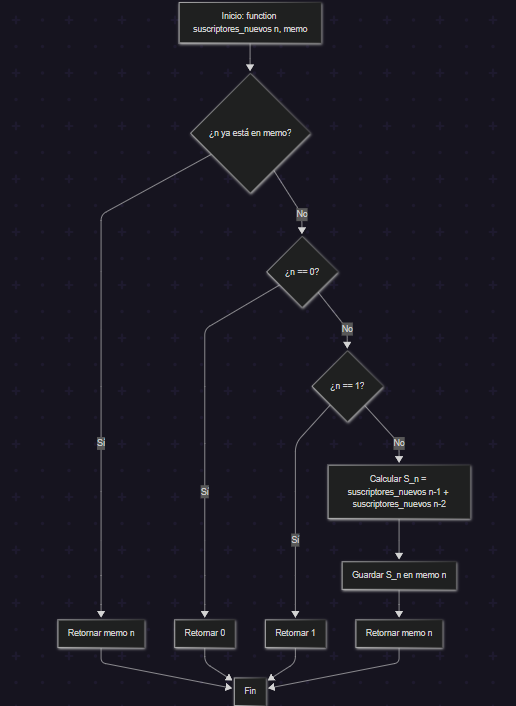

Descripcion:
Iniciamos nuestra solucion comprobando si ya hemos guardado el resultado de n en nuestra lista de memoizacion, si es asi retornamos ese valor ya que previamente lo habiamos solucionado, de lo contrario validamos casos base, si n=0 entonces retornamos 0, si n=1 entonces retornamos 1, de lo contrario calculamos gracias a nuestra funcion el valor de n (s(n-1)+s(n-2)), guardamos ese valor de nuestra solucion en memo y finalmente retornamos la solucion.

### 5) Análisis de complejidad **[15 pts]**
#### Funcion T(n)
T(n) = T(n-1) + T(n-2) para todo n >= 2
con T(0)=0 y T(1)=1
#### Mejor caso:
O(1): ocurre cuando el valor que necesitamos es un caso base, por lo que no se entraria directamente a nuestro calculo de T(n), o cuando el valor buscado ya lo hemos solicitado en una ocasion anterior y se encuentra guardado en nuestra lista de memoizacion.

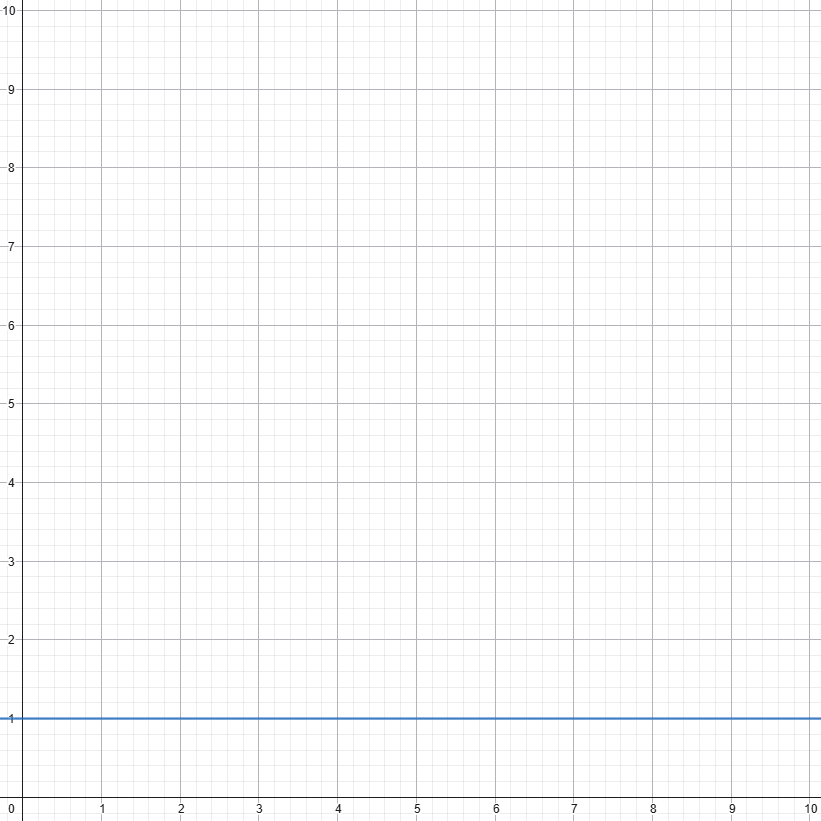


#### Peor caso:
O(n): Ocurre cuando se solicita n por primera vez. Aunque hay una doble llamada recursiva, la memoizacion garantiza que cada valor desde 2 hasta n se calcule exactamente una vez, sin la meoizacion nuestra complejidad seria O(2^n)

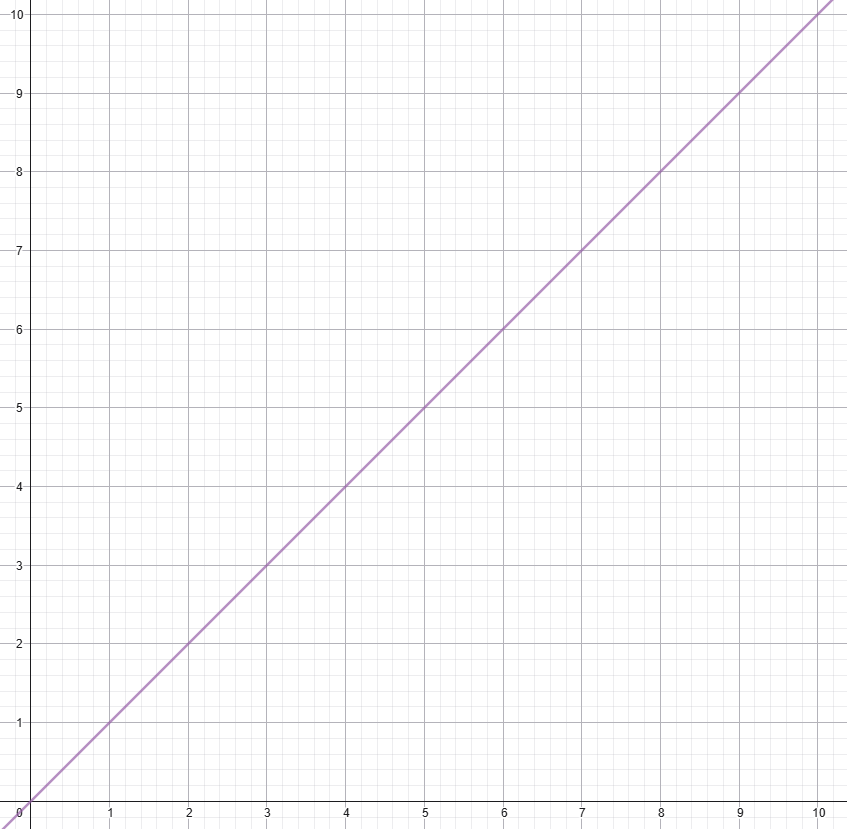




## 6) Código funcional **[15 pts]**


In [5]:
def solicitar_numero():
    mes = -1
    while mes < 0:
        mes = int(input("Ingrese el mes para calcular la cantidad de suscriptores, este debe ser un numero sin espacios, comas o puntos intermedios, ademas debe ser positivo: "))
        if mes < 0: 
            print("Error, el mes no puede ser negativo")
    return mes

def suscriptores_nuevos(n, memo=None):
    if memo is None:
        memo = {}
    if n in memo:
        return memo[n]
    if n == 0:
        return 0
    if n == 1:
        return 1
    resultado = suscriptores_nuevos(n-1, memo) + suscriptores_nuevos(n-2, memo)
    memo[n] = resultado
    return resultado

# =================== TESTS =======================

def ejecutar_pruebas():
    assert suscriptores_nuevos(0) == 0, "Error, en el mes 0 retornar 0"
    assert suscriptores_nuevos(1) == 1, "Error en el mes 1 retornar 1"
    assert suscriptores_nuevos(2) == 1, "Error en el mes 2"
    assert suscriptores_nuevos(3) == 2, "Error en el mes 3"
    assert suscriptores_nuevos(4) == 3, "Error en el mes 4"
    assert suscriptores_nuevos(5) == 5, "Error en el mes 5"
    assert suscriptores_nuevos(10) == 55, "Error en el mes 10"
    assert suscriptores_nuevos(50) == 12586269025, "Error en el mes 50"
    print("Todas las pruebas pasaron exitosamente.")


def main():
    print("--- SISTEMA DE SUSCRIPTORES POR MES  ---")
    ejecutar_pruebas()
    print("---------------------")
    mes_solicitado = solicitar_numero()
    total_suscriptores = suscriptores_nuevos(mes_solicitado)
    print(f"En el mes {mes_solicitado}, se registraron {total_suscriptores} suscriptores.")
main()

--- SISTEMA DE SUSCRIPTORES POR MES  ---
Todas las pruebas pasaron exitosamente.
---------------------
En el mes 9, se registraron 34 suscriptores.


## 7) Tests aplicados **[15 pts]**

Se agrega unicamente la funcion de los tests.

In [6]:
def ejecutar_pruebas():
    assert suscriptores_nuevos(0) == 0, "Error, en el mes 0 retornar 0"
    assert suscriptores_nuevos(1) == 1, "Error en el mes 1 retornar 1"
    assert suscriptores_nuevos(2) == 1, "Error en el mes 2"
    assert suscriptores_nuevos(3) == 2, "Error en el mes 3"
    assert suscriptores_nuevos(4) == 3, "Error en el mes 4"
    assert suscriptores_nuevos(5) == 5, "Error en el mes 5"
    assert suscriptores_nuevos(10) == 55, "Error en el mes 10"
    assert suscriptores_nuevos(50) == 12586269025, "Error en el mes 50"
    print("Todas las pruebas pasaron exitosamente.")
